In [4]:
import os
import mlflow

TRACKING_URI = os.getenv(
    "MLFLOW_TRACKING_URI",
    "MLFLOW_TRACKING_URI_LOCAL",
    # mlflow.set_tracking_uri("http://127.0.0.1:5000")
)

mlflow.set_tracking_uri(TRACKING_URI)


# Set or create an experiment
mlflow.set_experiment("Experiment of Handling Imbalanced Data")

2026/05/09 02:41:05 INFO mlflow.tracking.fluent: Experiment with name 'Experiment of Handling Imbalanced Data' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mohammed-mlflow-bucket/9', creation_time=1778280067857, experiment_id='9', last_update_time=1778280067857, lifecycle_stage='active', name='Experiment of Handling Imbalanced Data', tags={}, trace_location=None, workspace='default'>

### Delete an Experiment

In [ ]:
# import mlflow

# # 1. Get the experiment details by name
# experiment = mlflow.get_experiment_by_name("Exp 4 - Handling Imbalanced Data")

# # 2. Delete it using its experiment_id
# if experiment:
#     mlflow.delete_experiment(experiment.experiment_id)
#     print(f"Experiment '{experiment.name}' deleted successfully.")
# else:
#     print("Experiment not found.")


In [7]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [8]:
import pandas as pd

# 1. Load the data
df_clean = pd.read_csv('data/processed/cleaned_data.csv')

# 2. Map categories (-1 -> 2, 1 -> 1, 0 -> 0)
df_clean['category'] = df_clean['category'].map({-1: 2, 1: 1, 0: 0})

# 3. Check results
df_clean.head()


,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,2
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [10]:
df_clean.shape

(36662, 2)

### Let's Remember Together

### Compare over-sampling samplers


In [11]:
print(__doc__)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("poster")

Automatically created module for IPython interactive environment


> The following function will be used to create toy dataset. It uses the make_classification from scikit-learn but fixing some parameters.

In [12]:
from sklearn.datasets import make_classification


def create_dataset(
    n_samples=1000,
    weights=(0.01, 0.01, 0.98),
    n_classes=3,
    class_sep=0.8,
    n_clusters=1,
):
    return make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_repeated=0,
        n_classes=n_classes,
        n_clusters_per_class=n_clusters,
        weights=list(weights),
        class_sep=class_sep,
        random_state=0,
    )

> The following function will be used to plot the sample space after resampling to illustrate the specificities of an algorithm.

In [13]:
def plot_resampling(X, y, sampler, ax, title=None):
    X_res, y_res = sampler.fit_resample(X, y)
    ax.scatter(X_res[:, 0], X_res[:, 1], c=y_res, alpha=0.8, edgecolor="k")
    if title is None:
        title = f"Resampling with {sampler.__class__.__name__}"
    ax.set_title(title)
    sns.despine(ax=ax, offset=10)

> The following function will be used to plot the decision function of a classifier given some data.



In [14]:
import numpy as np


def plot_decision_function(X, y, clf, ax, title=None):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.8, c=y, edgecolor="k")
    if title is not None:
        ax.set_title(title)

#### Illustration of the influence of the balancing ratio
> We will first illustrate the influence of the balancing ratio on some toy data using a logistic regression classifier which is a linear model.

In [15]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

> We will fit and show the decision boundary model to illustrate the impact of dealing with imbalanced classes.

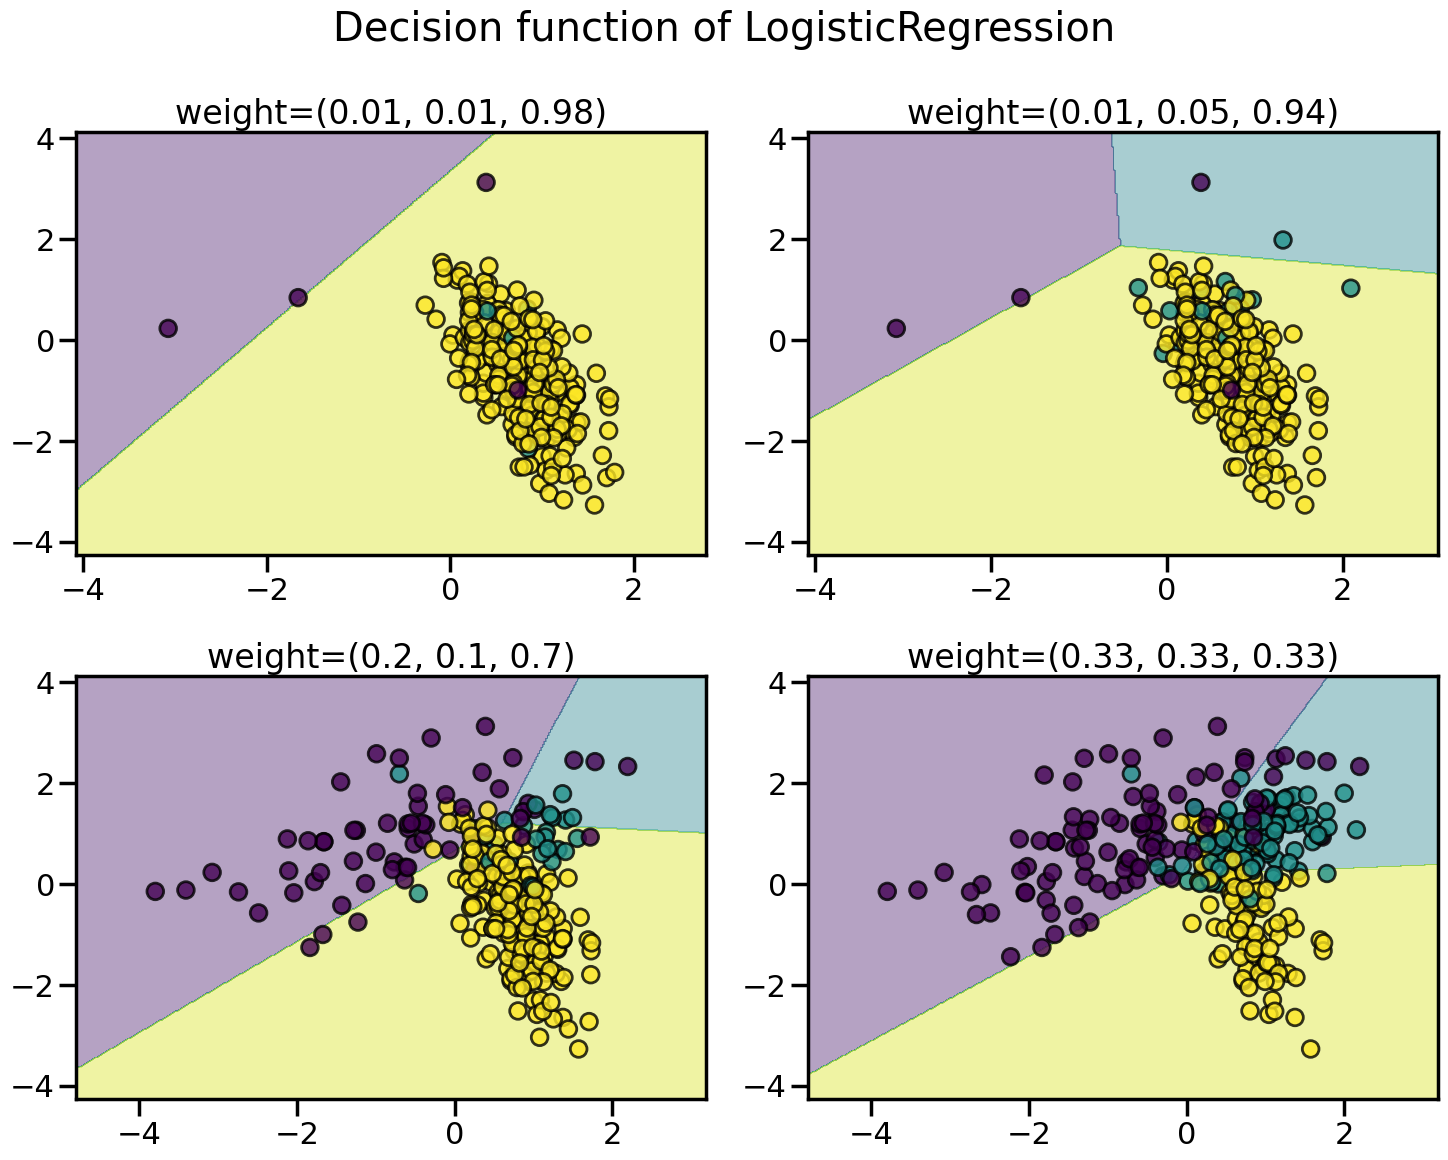

In [16]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

weights_arr = (
    (0.01, 0.01, 0.98),
    (0.01, 0.05, 0.94),
    (0.2, 0.1, 0.7),
    (0.33, 0.33, 0.33),
)
for ax, weights in zip(axs.ravel(), weights_arr):
    X, y = create_dataset(n_samples=300, weights=weights)
    clf.fit(X, y)
    plot_decision_function(X, y, clf, ax, title=f"weight={weights}")
    fig.suptitle(f"Decision function of {clf.__class__.__name__}")
fig.tight_layout()

### Random over-sampling to balance the data set
> Random over-sampling can be used to repeat some samples and balance the number of samples between the dataset. It can be seen that with this trivial approach the boundary decision is already less biased toward the majority class. The class RandomOverSampler implements such of a strategy.

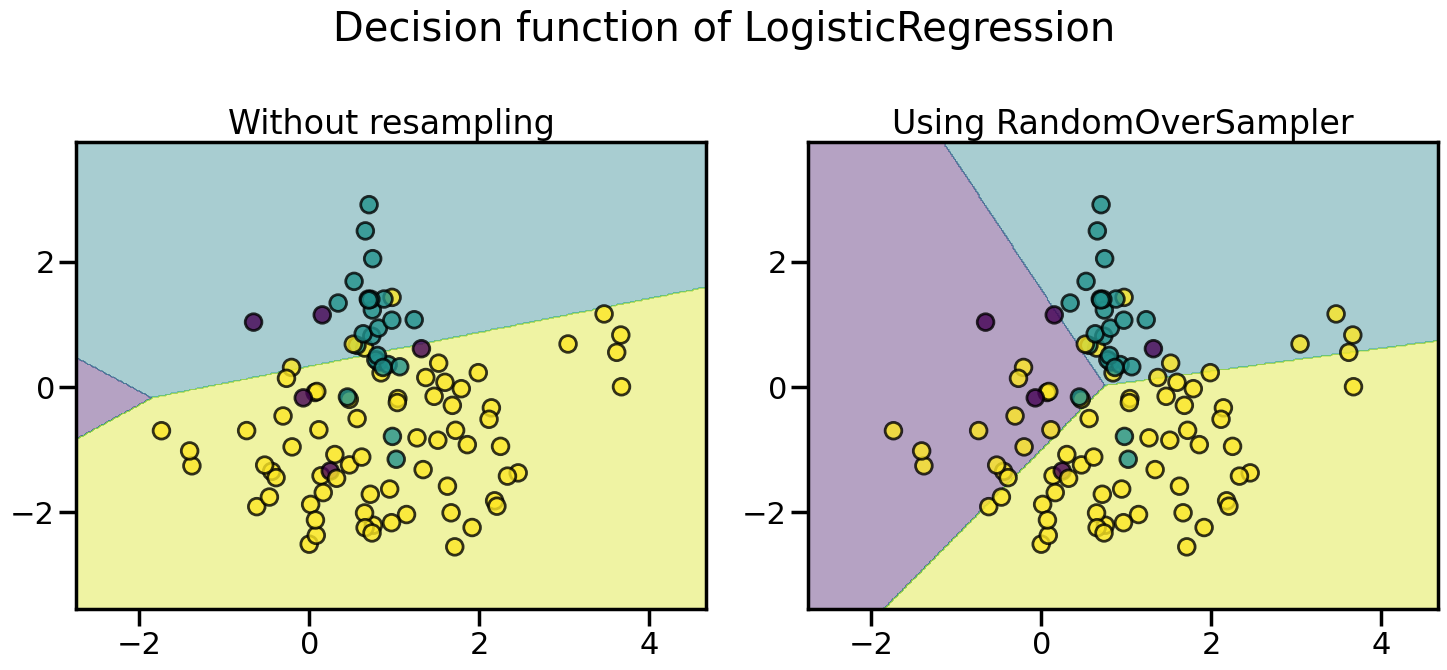

In [17]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import make_pipeline

X, y = create_dataset(n_samples=100, weights=(0.05, 0.25, 0.7))

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))

clf.fit(X, y)
plot_decision_function(X, y, clf, axs[0], title="Without resampling")

sampler = RandomOverSampler(random_state=0)
model = make_pipeline(sampler, clf).fit(X, y)
plot_decision_function(X, y, model, axs[1], f"Using {model[0].__class__.__name__}")

fig.suptitle(f"Decision function of {clf.__class__.__name__}")
fig.tight_layout()

> By default, random over-sampling generates a bootstrap. The parameter shrinkage allows adding a small perturbation to the generated data to generate a smoothed bootstrap instead. The plot below shows the difference between the two data generation strategies.

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))

sampler.set_params(shrinkage=None)
plot_resampling(X, y, sampler, ax=axs[0], title="Normal bootstrap")

sampler.set_params(shrinkage=0.3)
plot_resampling(X, y, sampler, ax=axs[1], title="Smoothed bootstrap")

fig.suptitle(f"Resampling with {sampler.__class__.__name__}")
fig.tight_layout()

### More advanced over-sampling using ADASYN and SMOTE

> Instead of repeating the same samples when over-sampling or perturbating the generated bootstrap samples, one can use some specific heuristic instead. ADASYN and SMOTE can be used in this case.

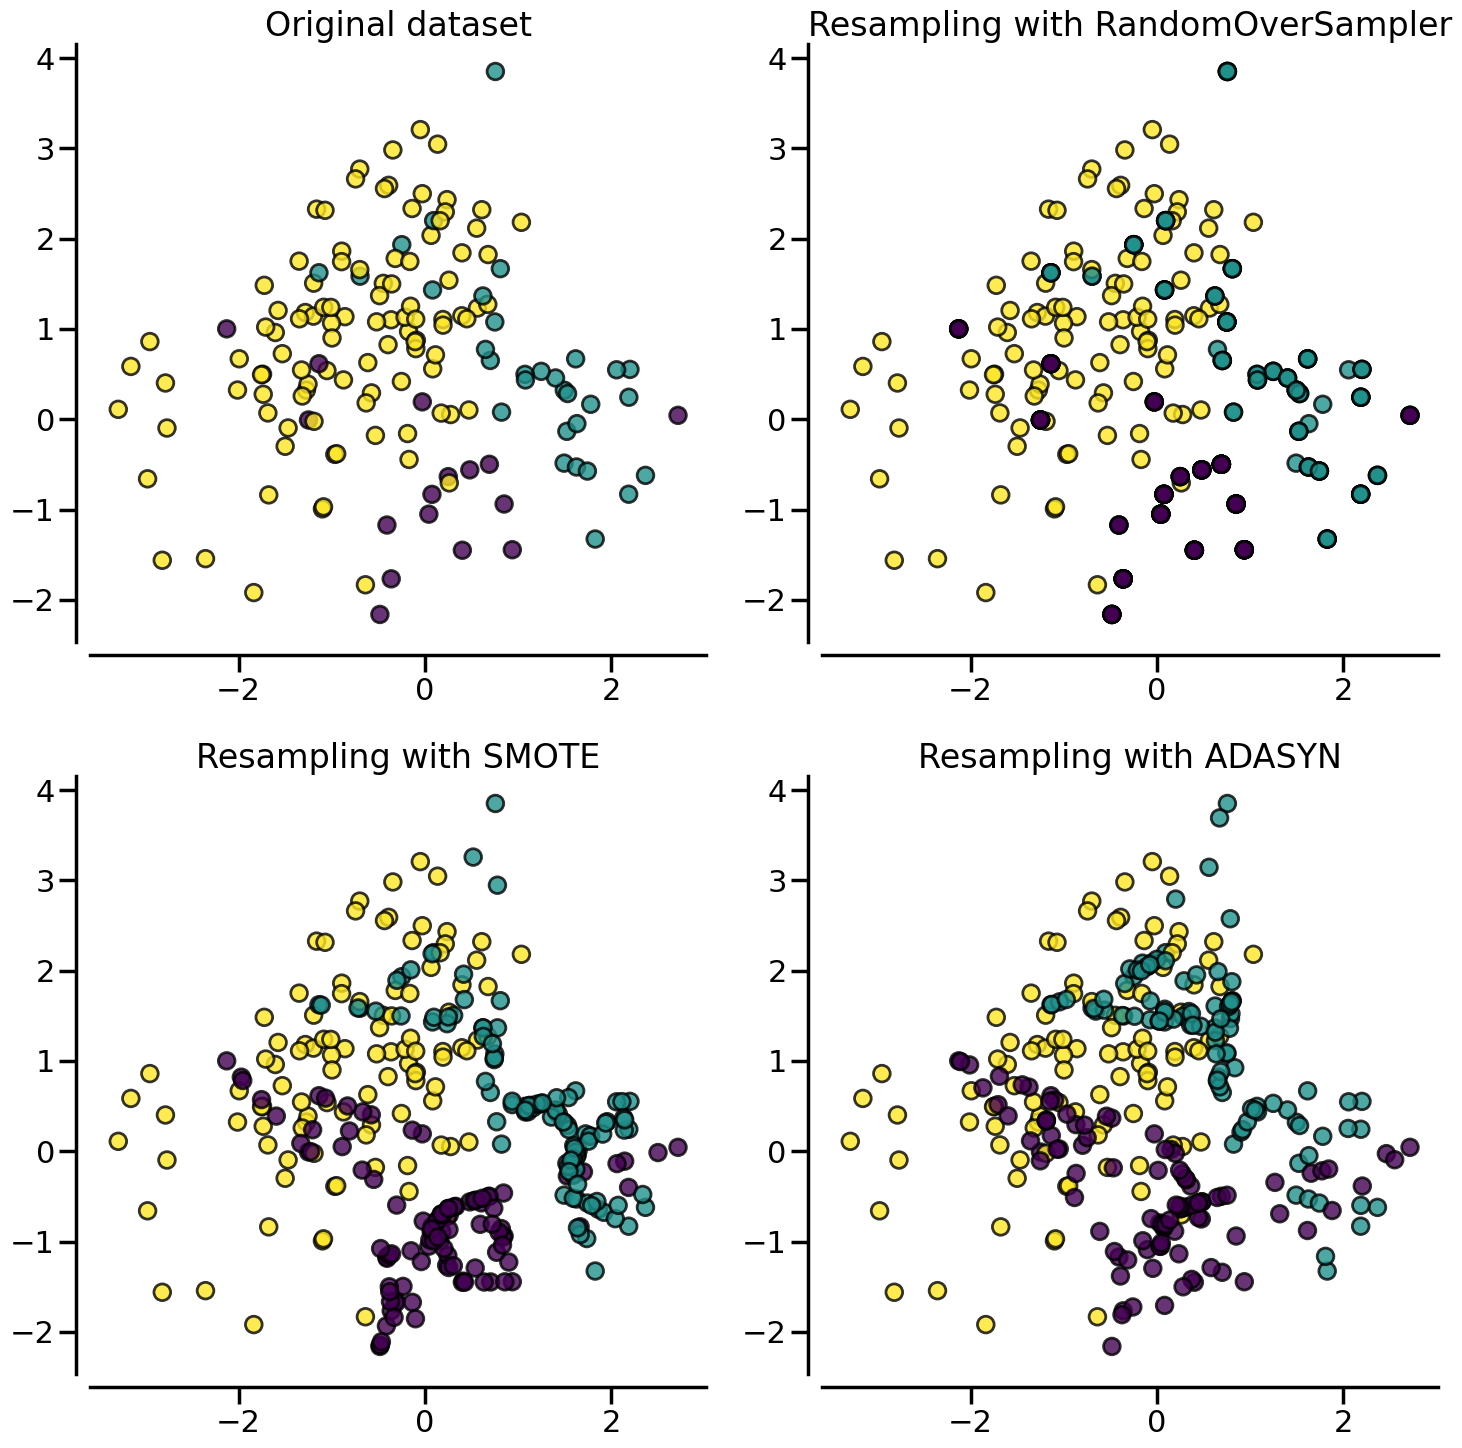

In [18]:
from imblearn import FunctionSampler  # to use a idendity sampler
from imblearn.over_sampling import ADASYN, SMOTE

X, y = create_dataset(n_samples=150, weights=(0.1, 0.2, 0.7))

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))

samplers = [
    FunctionSampler(),
    RandomOverSampler(random_state=0),
    SMOTE(random_state=0),
    ADASYN(random_state=0),
]

for ax, sampler in zip(axs.ravel(), samplers):
    title = "Original dataset" if isinstance(sampler, FunctionSampler) else None
    plot_resampling(X, y, sampler, ax, title=title)
fig.tight_layout()

> The following plot illustrates the difference between ADASYN and SMOTE. ADASYN will focus on the samples which are difficult to classify with a nearest-neighbors rule while regular SMOTE will not make any distinction. Therefore, the decision function depending of the algorithm.

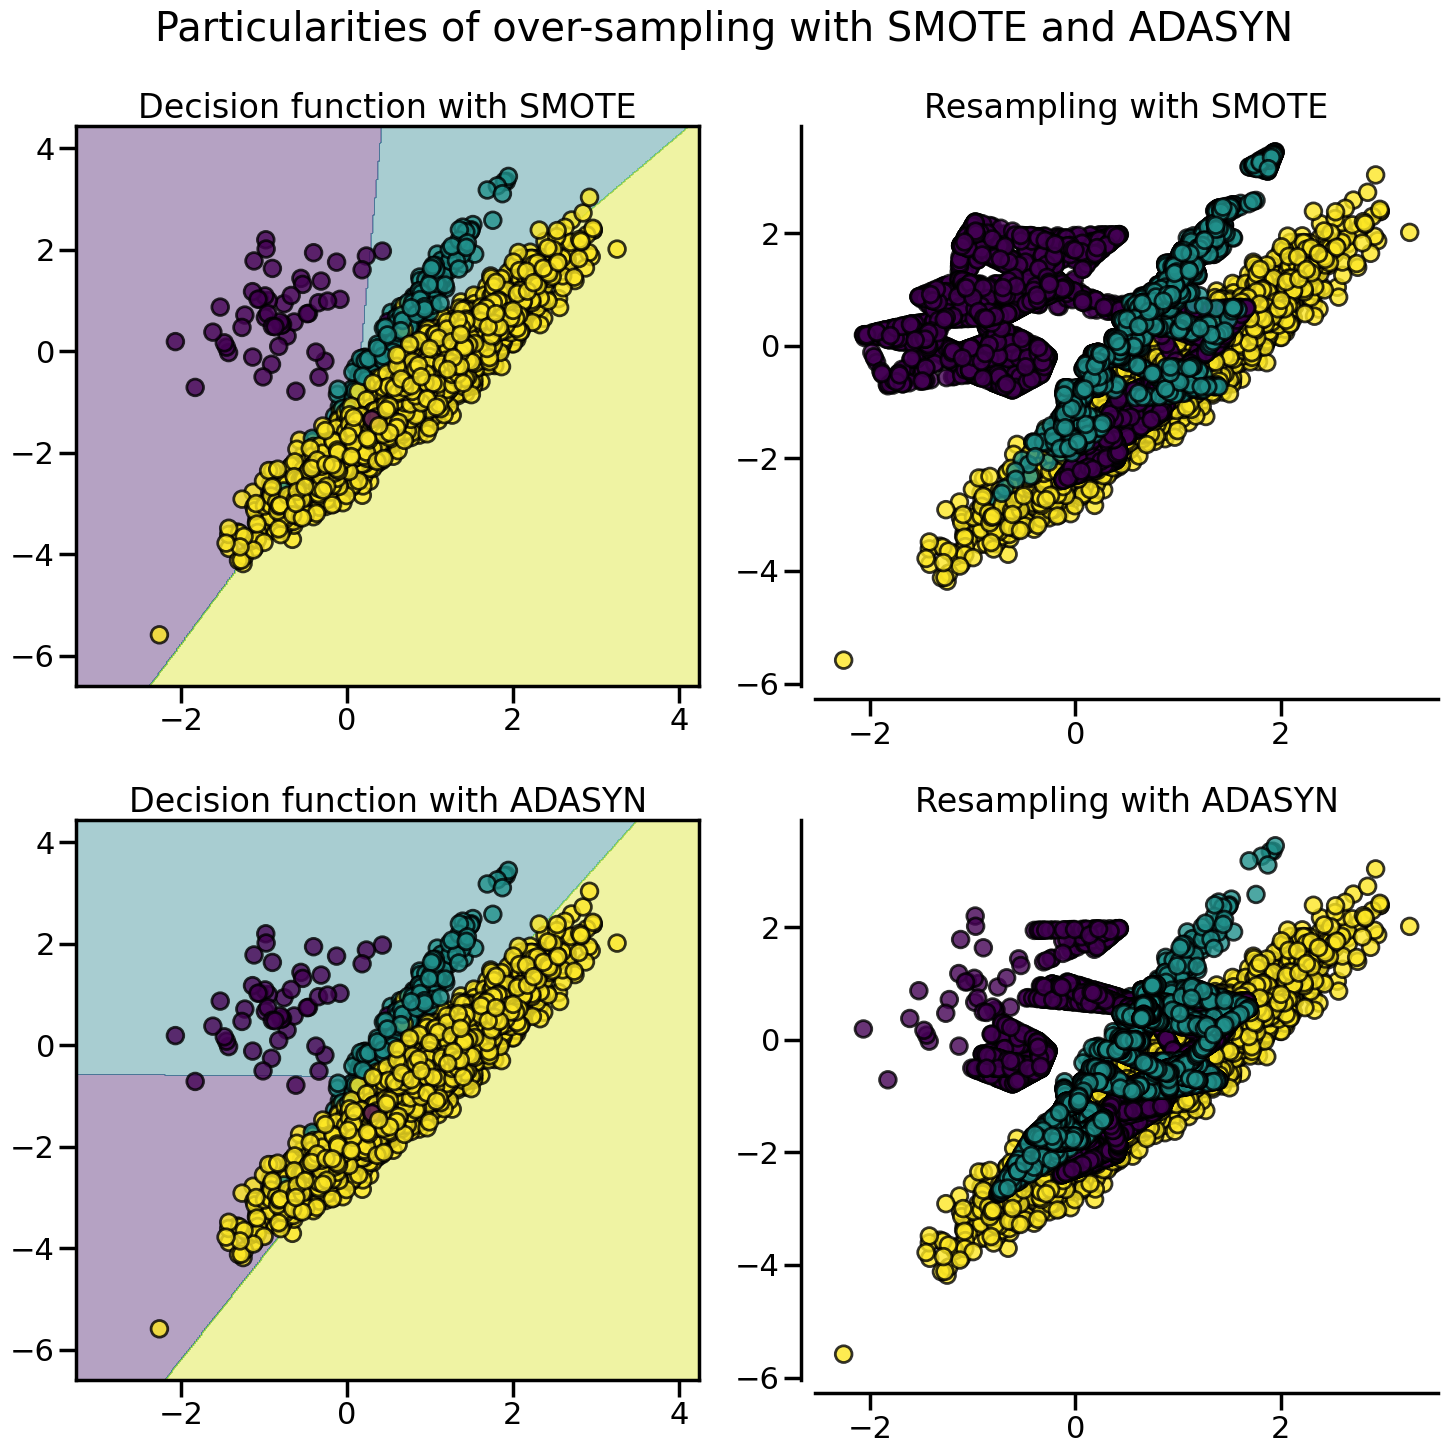

In [19]:
X, y = create_dataset(n_samples=5000, weights=(0.01, 0.05, 0.94), class_sep=0.8)

samplers = [SMOTE(random_state=0), ADASYN(random_state=0)]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))
for ax, sampler in zip(axs, samplers):
    model = make_pipeline(sampler, clf).fit(X, y)
    plot_decision_function(
        X, y, clf, ax[0], title=f"Decision function with {sampler.__class__.__name__}"
    )
    plot_resampling(X, y, sampler, ax[1])

fig.suptitle("Particularities of over-sampling with SMOTE and ADASYN")
fig.tight_layout()

> Due to those sampling particularities, it can give rise to some specific issues as illustrated below.

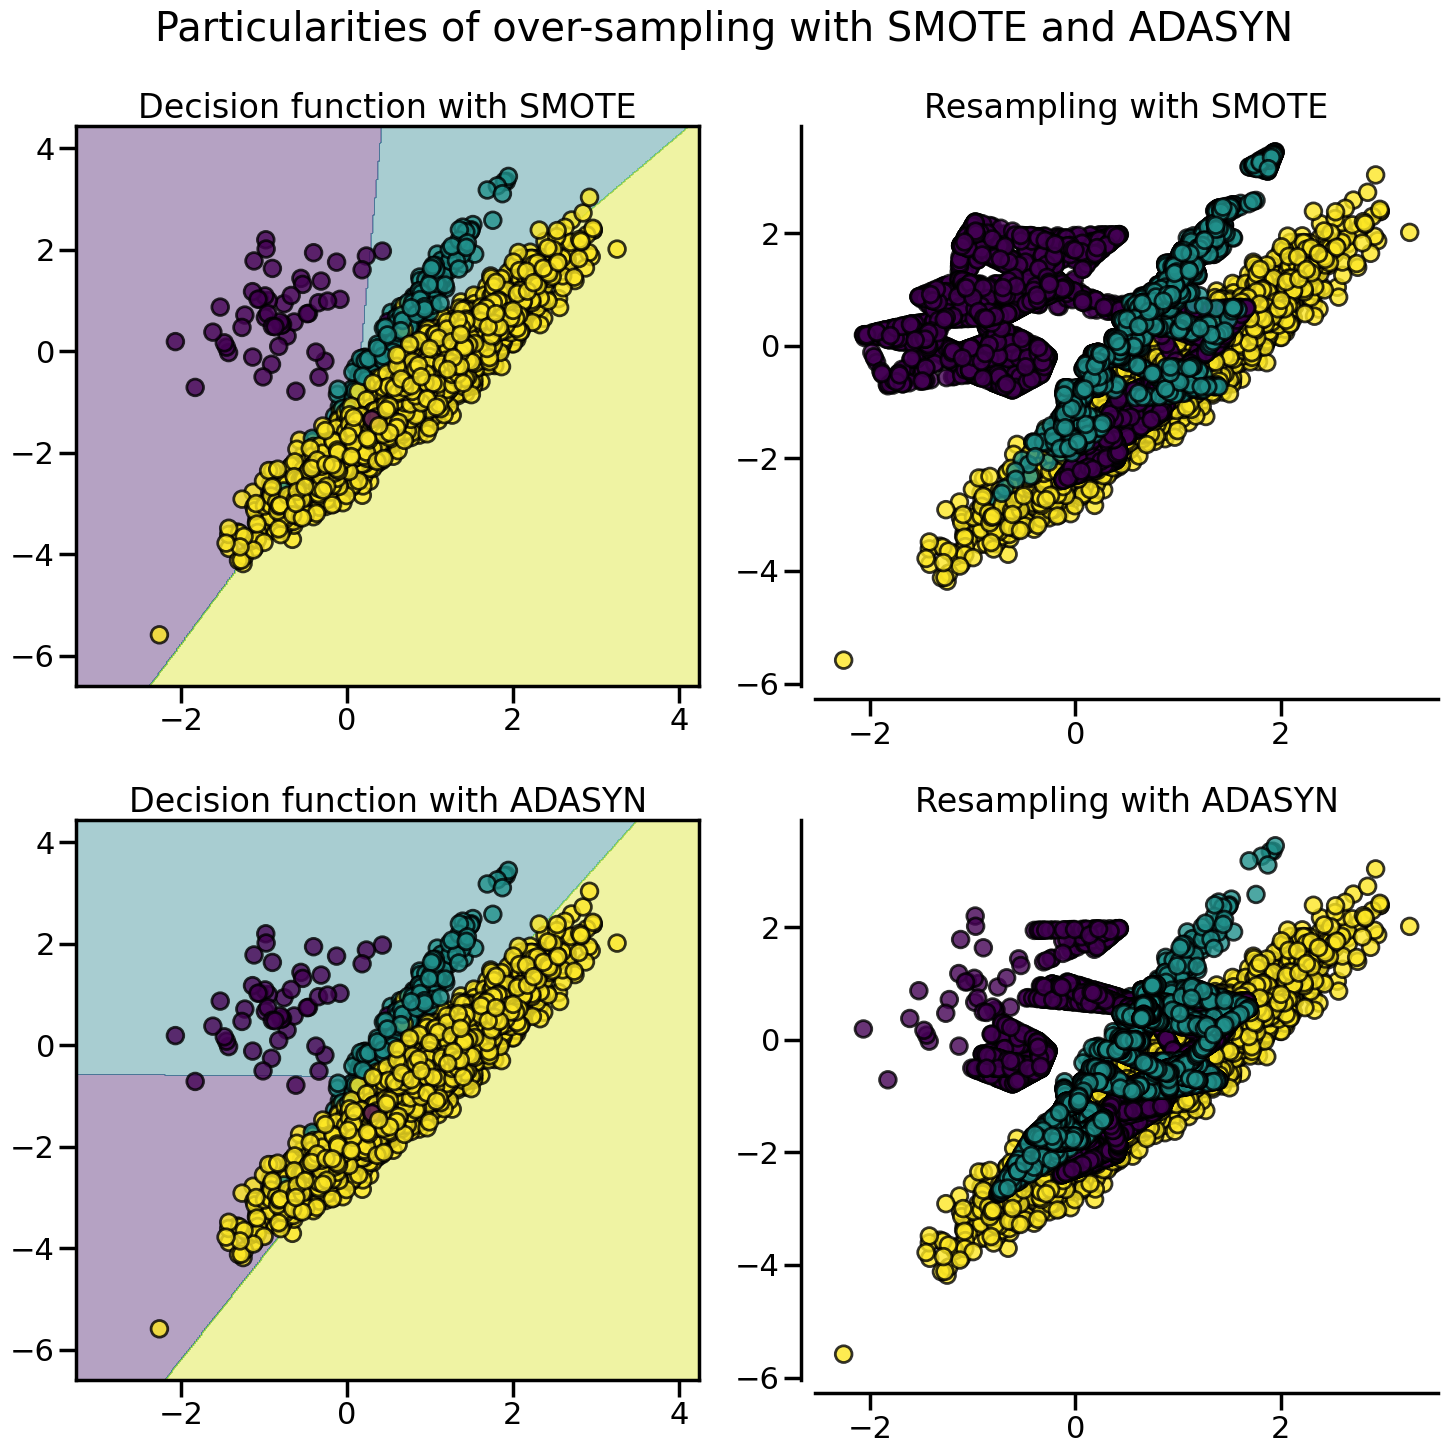

In [20]:
X, y = create_dataset(n_samples=5000, weights=(0.01, 0.05, 0.94), class_sep=0.8)

samplers = [SMOTE(random_state=0), ADASYN(random_state=0)]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))
for ax, sampler in zip(axs, samplers):
    model = make_pipeline(sampler, clf).fit(X, y)
    plot_decision_function(
        X, y, clf, ax[0], title=f"Decision function with {sampler.__class__.__name__}"
    )
    plot_resampling(X, y, sampler, ax[1])

fig.suptitle("Particularities of over-sampling with SMOTE and ADASYN")
fig.tight_layout()

> SMOTE proposes several variants by identifying specific samples to consider during the resampling. The borderline version (BorderlineSMOTE) will detect which point to select which are in the border between two classes. The SVM version (SVMSMOTE) will use the support vectors found using an SVM algorithm to create new sample while the KMeans version (KMeansSMOTE) will make a clustering before to generate samples in each cluster independently depending each cluster density.

In [ ]:
from sklearn.cluster import MiniBatchKMeans

from imblearn.over_sampling import SVMSMOTE, BorderlineSMOTE, KMeansSMOTE

X, y = create_dataset(n_samples=5000, weights=(0.01, 0.05, 0.94), class_sep=0.8)

fig, axs = plt.subplots(5, 2, figsize=(15, 30))

samplers = [
    SMOTE(random_state=0),
    BorderlineSMOTE(random_state=0, kind="borderline-1"),
    BorderlineSMOTE(random_state=0, kind="borderline-2"),
    KMeansSMOTE(
        kmeans_estimator=MiniBatchKMeans(n_clusters=10, n_init=1, random_state=0),
        random_state=0,
    ),
    SVMSMOTE(random_state=0),
]

for ax, sampler in zip(axs, samplers):
    model = make_pipeline(sampler, clf).fit(X, y)
    plot_decision_function(
        X, y, clf, ax[0], title=f"Decision function for {sampler.__class__.__name__}"
    )
    plot_resampling(X, y, sampler, ax[1])

fig.suptitle("Decision function and resampling using SMOTE variants")
fig.tight_layout()

> When dealing with a mixed of continuous and categorical features, SMOTENC is the only method which can handle this case.

In [21]:
from collections import Counter

from imblearn.over_sampling import SMOTENC

rng = np.random.RandomState(42)
n_samples = 50
# Create a dataset of a mix of numerical and categorical data
X = np.empty((n_samples, 3), dtype=object)
X[:, 0] = rng.choice(["A", "B", "C"], size=n_samples).astype(object)
X[:, 1] = rng.randn(n_samples)
X[:, 2] = rng.randint(3, size=n_samples)
y = np.array([0] * 20 + [1] * 30)

print("The original imbalanced dataset")
print(sorted(Counter(y).items()))
print()
print("The first and last columns are containing categorical features:")
print(X[:5])
print()

smote_nc = SMOTENC(categorical_features=[0, 2], random_state=0)
X_resampled, y_resampled = smote_nc.fit_resample(X, y)
print("Dataset after resampling:")
print(sorted(Counter(y_resampled).items()))
print()
print("SMOTE-NC will generate categories for the categorical features:")
print(X_resampled[-5:])
print()

The original imbalanced dataset
[(np.int64(0), 20), (np.int64(1), 30)]

The first and last columns are containing categorical features:
[['C' -0.14021849735700803 2]
 ['A' -0.033193400066544886 2]
 ['C' -0.7490765234433554 1]
 ['C' -0.7783820070908942 2]
 ['A' 0.948842857719016 2]]

Dataset after resampling:
[(np.int64(0), 30), (np.int64(1), 30)]

SMOTE-NC will generate categories for the categorical features:
[['A' 0.1989993778979113 2]
 ['B' -0.3657680728116921 2]
 ['B' 0.8790828729585258 2]
 ['B' 0.3710891618824609 2]
 ['B' 0.3327240726719727 2]]



In [22]:
from imblearn.over_sampling import SMOTEN

# Generate only categorical data
X = np.array(["A"] * 10 + ["B"] * 20 + ["C"] * 30, dtype=object).reshape(-1, 1)
y = np.array([0] * 20 + [1] * 40, dtype=np.int32)

print(f"Original class counts: {Counter(y)}")
print()
print(X[:5])
print()

sampler = SMOTEN(random_state=0)
X_res, y_res = sampler.fit_resample(X, y)
print(f"Class counts after resampling {Counter(y_res)}")
print()
print(X_res[-5:])
print()

Original class counts: Counter({np.int32(1): 40, np.int32(0): 20})

[['A']
 ['A']
 ['A']
 ['A']
 ['A']]

Class counts after resampling Counter({np.int32(0): 40, np.int32(1): 40})

[['B']
 ['B']
 ['A']
 ['B']
 ['A']]



#### 🏗️ Design Pattern: Strategy Pattern

We’ll implement:

```
VectorizerFactory
ModelFactory
Trainer (uses both)
```

#### 🧠 Why this design is correct

#### ✔ SOLID principles applied
#### 1. Open/Closed Principle
You can add new models without touching trainer

#### 2. Strategy Pattern

Model + vectorizer are interchangeable

#### 3. Separation of concerns

* Factory → creation
* Trainer → logic
* MLflow → tracking

### 1. Imbalance Factory

In [23]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN


class ImbalanceHandlerFactory:

    @staticmethod
    def get(name: str, random_state=42):

        name = name.lower()

        handlers = {
            "oversampling": SMOTE(random_state=random_state),
            "adasyn": ADASYN(random_state=random_state),
            "undersampling": RandomUnderSampler(random_state=random_state),
            "smote_enn": SMOTEENN(random_state=random_state),
        }

        return handlers.get(name)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


class VectorizerFactory:
    @staticmethod
    def get(name: str, ngram_range=(1, 1), max_features=8000):
        name = name.lower()

        if name == "tfidf":
            return TfidfVectorizer(
                ngram_range=ngram_range,
                max_features=max_features
            )

        elif name == "count":
            return CountVectorizer(
                ngram_range=ngram_range,
                max_features=max_features
            )

        else:
            raise ValueError(f"Unknown vectorizer: {name}")

In [28]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


class ModelFactory:
    @staticmethod
    def get(name: str, random_state=42):

        name = name.lower()

        if name == "random_forest":
            return RandomForestClassifier(
                n_estimators=800,
                max_depth=15,
                random_state=random_state
            )

        elif name == "xgboost":
            return XGBClassifier(
                n_estimators=300,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=random_state
            )

        elif name == "lightgbm":
            return LGBMClassifier(
                n_estimators=300,
                learning_rate=0.1,
                random_state=random_state
            )

        else:
            raise ValueError(f"Unknown model: {name}")

### 2. Refactored Trainer

In [24]:
import os
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder


class ImbalanceExperimentTrainer:

    def __init__(
        self,
        experiment_name="Imbalance_Experiments",
        text_column="clean_comment",
        target_column="category",
        test_size=0.2,
        random_state=42
    ):

        self.text_column = text_column
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state

        self.label_encoder = LabelEncoder()

        mlflow.set_tracking_uri("https://mlflow-dashboard.duckdns.org")
        mlflow.set_experiment(experiment_name)

    # ======================
    # Label Encoding
    # ======================
    def _encode_labels(self, y):
        return self.label_encoder.fit_transform(y)

    # ======================
    # Feature Casting
    # ======================
    def _cast_features(self, X, model_name):

        if model_name.lower() in ["lightgbm", "xgboost"]:
            return X.astype("float32")

        return X

    # ======================
    # Run Experiment
    # ======================
    def train(
        self,
        df,
        vectorizer_name="tfidf",
        model_name="random_forest",
        imbalance_method="class_weights",
        ngram_range=(1, 3),
        max_features=10000
    ):

        # ======================
        # Clean data
        # ======================
        df = df.copy()

        df[self.text_column] = df[self.text_column].fillna("")
        df[self.target_column] = df[self.target_column].fillna("unknown")

        X = df[self.text_column]
        y = self._encode_labels(df[self.target_column])

        # ======================
        # Split
        # ======================
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y
        )

        # ======================
        # Build vectorizer/model
        # ======================
        vectorizer = VectorizerFactory.get(
            vectorizer_name,
            ngram_range=ngram_range,
            max_features=max_features
        )

        model = ModelFactory.get(
            model_name,
            random_state=self.random_state
        )

        # ======================
        # Vectorize
        # ======================
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        # ======================
        # Resampling strategy
        # ======================
        class_weight = None

        if imbalance_method == "class_weights":

            if hasattr(model, "class_weight"):
                model.set_params(class_weight="balanced")

        else:

            sampler = ImbalanceHandlerFactory.get(
                imbalance_method,
                random_state=self.random_state
            )

            if sampler:
                X_train_vec, y_train = sampler.fit_resample(
                    X_train_vec,
                    y_train
                )

        # ======================
        # Casting
        # ======================
        X_train_vec = self._cast_features(
            X_train_vec,
            model_name
        )

        X_test_vec = self._cast_features(
            X_test_vec,
            model_name
        )

        # ======================
        # MLflow
        # ======================
        with mlflow.start_run():

            # ======================
            # Params
            # ======================
            mlflow.log_param("vectorizer", vectorizer_name)
            mlflow.log_param("model", model_name)
            mlflow.log_param("imbalance_method", imbalance_method)
            mlflow.log_param("ngram_range", str(ngram_range))
            mlflow.log_param("max_features", max_features)

            # ======================
            # Train
            # ======================
            model.fit(X_train_vec, y_train)

            # ======================
            # Predict
            # ======================
            y_pred = model.predict(X_test_vec)

            # ======================
            # Metrics
            # ======================
            acc = accuracy_score(y_test, y_pred)

            report = classification_report(
                y_test,
                y_pred,
                output_dict=True
            )

            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric(
                "f1_macro",
                report["macro avg"]["f1-score"]
            )

            mlflow.log_metric(
                "precision_macro",
                report["macro avg"]["precision"]
            )

            mlflow.log_metric(
                "recall_macro",
                report["macro avg"]["recall"]
            )

            # ======================
            # Confusion Matrix
            # ======================
            cm = confusion_matrix(y_test, y_pred)

            plt.figure(figsize=(8, 6))

            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues"
            )

            plt.title(
                f"{model_name} | {imbalance_method}"
            )

            os.makedirs("artifacts", exist_ok=True)

            cm_path = f"artifacts/cm_{imbalance_method}.png"

            plt.savefig(cm_path)

            plt.close()

            mlflow.log_artifact(cm_path)

            # ======================
            # Log model
            # ======================
            mlflow.sklearn.log_model(
                model,
                artifact_path="model"
            )

            print(f"Accuracy: {acc:.4f}")
            print(classification_report(y_test, y_pred))

        return model, vectorizer

### 3. Run All Imbalance Experiments

In [29]:
trainer = ImbalanceExperimentTrainer()

imbalance_methods = [
    "class_weights",
    "oversampling",
    "adasyn",
    "undersampling",
    "smote_enn"
]

for method in imbalance_methods:

    trainer.train(
        df=df_clean,
        vectorizer_name="tfidf",
        model_name="random_forest",
        imbalance_method=method,
        ngram_range=(1, 3),
        max_features=10000
    )

2026/05/09 03:43:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 03:43:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.6809
              precision    recall  f1-score   support

           0       0.59      0.94      0.73      2529
           1       0.83      0.61      0.70      3154
           2       0.69      0.41      0.52      1650

    accuracy                           0.68      7333
   macro avg       0.70      0.66      0.65      7333
weighted avg       0.72      0.68      0.67      7333

🏃 View run amazing-goat-669 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/d295888652f54ef5a7bb883d272cc54e
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 03:47:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 03:47:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.6872
              precision    recall  f1-score   support

           0       0.60      0.94      0.73      2529
           1       0.83      0.62      0.71      3154
           2       0.69      0.42      0.52      1650

    accuracy                           0.69      7333
   macro avg       0.71      0.66      0.66      7333
weighted avg       0.72      0.69      0.68      7333

🏃 View run bright-lynx-40 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/3aeebdf1303d40fe8e9596f598c3f728
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 03:49:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 03:49:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.6358
              precision    recall  f1-score   support

           0       0.54      0.96      0.70      2529
           1       0.83      0.52      0.64      3154
           2       0.66      0.37      0.47      1650

    accuracy                           0.64      7333
   macro avg       0.68      0.61      0.60      7333
weighted avg       0.69      0.64      0.62      7333

🏃 View run omniscient-pig-729 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/36f2e374d3f14a52b8f2cbedebe4b8aa
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 03:50:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 03:50:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.6803
              precision    recall  f1-score   support

           0       0.59      0.94      0.73      2529
           1       0.85      0.58      0.69      3154
           2       0.66      0.47      0.55      1650

    accuracy                           0.68      7333
   macro avg       0.70      0.66      0.66      7333
weighted avg       0.72      0.68      0.67      7333

🏃 View run grandiose-goose-331 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/8a795eb90ad8450b950f7aada7e0456d
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 03:55:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 03:55:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.3531
              precision    recall  f1-score   support

           0       0.76      0.40      0.52      2529
           1       1.00      0.00      0.00      3154
           2       0.26      0.96      0.41      1650

    accuracy                           0.35      7333
   macro avg       0.67      0.45      0.31      7333
weighted avg       0.75      0.35      0.27      7333

🏃 View run awesome-ram-439 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/9744daf034114ae2add9180b4d76dc96
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


In [30]:
trainer = ImbalanceExperimentTrainer()

imbalance_methods = [
    "class_weights",
    "oversampling",
    "adasyn",
    "undersampling",
    "smote_enn"
]

for method in imbalance_methods:

    trainer.train(
        df=df_clean,
        vectorizer_name="tfidf",
        model_name="xgboost",
        imbalance_method=method,
        ngram_range=(1, 3),
        max_features=10000
    )

2026/05/09 04:31:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 04:31:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8047
              precision    recall  f1-score   support

           0       0.75      0.96      0.84      2529
           1       0.85      0.81      0.83      3154
           2       0.84      0.55      0.67      1650

    accuracy                           0.80      7333
   macro avg       0.81      0.77      0.78      7333
weighted avg       0.81      0.80      0.80      7333

🏃 View run delicate-fox-673 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/4349c1d83cd84643aa4464120868b2bc
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 04:36:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 04:36:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8043
              precision    recall  f1-score   support

           0       0.75      0.96      0.84      2529
           1       0.90      0.75      0.82      3154
           2       0.75      0.66      0.71      1650

    accuracy                           0.80      7333
   macro avg       0.80      0.79      0.79      7333
weighted avg       0.82      0.80      0.80      7333

🏃 View run fun-sponge-20 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/8b0a9deba7de470a963bd2b699386d8e
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 04:41:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 04:41:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8009
              precision    recall  f1-score   support

           0       0.74      0.96      0.84      2529
           1       0.91      0.74      0.82      3154
           2       0.75      0.66      0.70      1650

    accuracy                           0.80      7333
   macro avg       0.80      0.79      0.79      7333
weighted avg       0.81      0.80      0.80      7333

🏃 View run sneaky-cub-13 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/f1d2a5224d824d08a7323982d351daeb
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 04:43:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 04:43:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.7976
              precision    recall  f1-score   support

           0       0.75      0.95      0.84      2529
           1       0.91      0.73      0.81      3154
           2       0.71      0.69      0.70      1650

    accuracy                           0.80      7333
   macro avg       0.79      0.79      0.78      7333
weighted avg       0.81      0.80      0.80      7333

🏃 View run luminous-midge-932 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/f4555177c26649998175bbeb6942ea15
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


2026/05/09 04:45:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 04:45:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.5505
              precision    recall  f1-score   support

           0       0.68      0.86      0.76      2529
           1       0.98      0.14      0.25      3154
           2       0.38      0.85      0.53      1650

    accuracy                           0.55      7333
   macro avg       0.68      0.62      0.51      7333
weighted avg       0.74      0.55      0.49      7333

🏃 View run wise-koi-650 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/65fd913a0e474107a775bd11178cbb04
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


In [31]:
trainer = ImbalanceExperimentTrainer()

imbalance_methods = [
    "class_weights",
    "oversampling",
    "adasyn",
    "undersampling",
    "smote_enn"
]

for method in imbalance_methods:

    trainer.train(
        df=df_clean,
        vectorizer_name="tfidf",
        model_name="lightgbm",
        imbalance_method=method,
        ngram_range=(1, 3),
        max_features=10000
    )

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.676940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 130941
[LightGBM] [Info] Number of data points in the train set: 29329, number of used features: 4402
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


d:\MyFiles\GitHub\YouTube Viewer Sentiment Analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/05/09 14:34:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 14:34:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8679
              precision    recall  f1-score   support

           0       0.85      0.96      0.91      2529
           1       0.91      0.85      0.88      3154
           2       0.81      0.76      0.78      1650

    accuracy                           0.87      7333
   macro avg       0.86      0.86      0.86      7333
weighted avg       0.87      0.87      0.87      7333

🏃 View run invincible-hawk-155 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/e165b4bd8090441393d5af85d36c1070
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.175423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 171671
[LightGBM] [Info] Number of data points in the train set: 37848, number of used features: 5550
[LightGBM] [Info] Start training from scor

d:\MyFiles\GitHub\YouTube Viewer Sentiment Analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/05/09 14:38:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 14:38:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8760
              precision    recall  f1-score   support

           0       0.87      0.97      0.91      2529
           1       0.91      0.86      0.88      3154
           2       0.83      0.77      0.80      1650

    accuracy                           0.88      7333
   macro avg       0.87      0.87      0.87      7333
weighted avg       0.88      0.88      0.87      7333

🏃 View run amazing-cod-613 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/705ddb20429f44c5be2d6939ec1ad790
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.055365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 174869
[LightGBM] [Info] Number of data points in the train set: 39174, number of used features: 5638
[LightGBM] [Info] Start training from score -1.048139
[LightGBM] [Info] Start training from score -1.133047
[L

...

Accuracy: 0.8752
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2529
           1       0.91      0.86      0.88      3154
           2       0.83      0.77      0.80      1650

    accuracy                           0.88      7333
   macro avg       0.87      0.86      0.86      7333
weighted avg       0.88      0.88      0.87      7333

🏃 View run thundering-mule-182 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/5552d1493ffb4dd086a9b1dcdc877827
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.387032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 84457
[LightGBM] [Info] Number of data points in the train set: 19794, number of used features: 3017
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

d:\MyFiles\GitHub\YouTube Viewer Sentiment Analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/05/09 14:43:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 14:43:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8451
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2529
           1       0.91      0.80      0.85      3154
           2       0.76      0.77      0.76      1650

    accuracy                           0.85      7333
   macro avg       0.83      0.84      0.83      7333
weighted avg       0.85      0.85      0.84      7333

🏃 View run gentle-calf-713 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/3124e64a5f5040a7a66f11fabf7770d8
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 45305
[LightGBM] [Info] Number of data points in the train set: 13545, number of used features: 1893
[LightGBM] [Info] Start training from score -0.

d:\MyFiles\GitHub\YouTube Viewer Sentiment Analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/05/09 14:44:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 14:44:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.5685
              precision    recall  f1-score   support

           0       0.72      0.86      0.78      2529
           1       0.94      0.17      0.28      3154
           2       0.39      0.88      0.54      1650

    accuracy                           0.57      7333
   macro avg       0.68      0.64      0.54      7333
weighted avg       0.74      0.57      0.51      7333

🏃 View run rumbling-whale-126 at: https://mlflow-dashboard.duckdns.org/#/experiments/10/runs/5cb7c9be597046129f2c31ee204f1fd8
🧪 View experiment at: https://mlflow-dashboard.duckdns.org/#/experiments/10


##### 🔥 Next-Level Upgrade

You can now easily build:

```python
for model in models:
    for vectorizer in vectorizers:
        for imbalance in imbalance_methods:
            for ngram in ngrams:
```

→ full NLP benchmarking framework automatically tracked in MLflow.
